# Punkty Charakterystyczne 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy . ndimage . filters as filters
from scipy.ndimage import maximum_filter

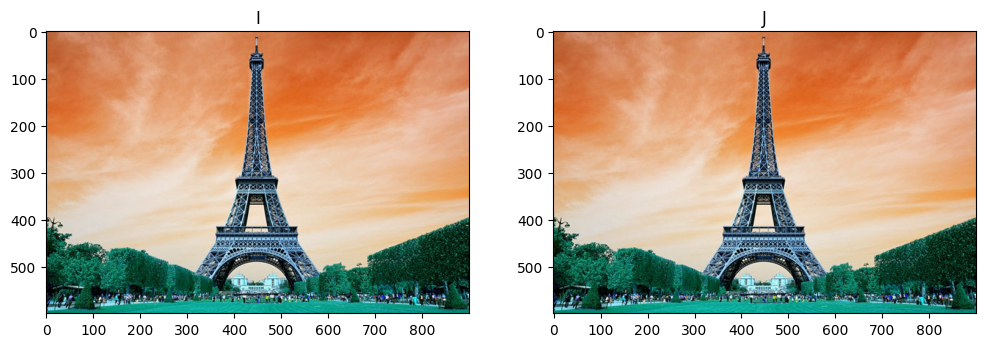

In [2]:
# I_path = 'fontanna1.jpg'
# J_path = 'fontanna2.jpg'

I_path = 'eiffel1.jpg'
J_path = 'eiffel1.jpg'

I = cv2.imread(I_path)
J = cv2.imread(J_path)


fig, axs = plt.subplots(1, 2, figsize=(12, 10))

axs[0].set_title("I")
axs[0].imshow(I)

axs[1].set_title("J")
axs[1].imshow(J)

In [3]:
class FP_Harris():
    def __init__(self):
        pass

    def Harris(self, gray: np.ndarray, sobel_size: int, gauss_size: int) -> np.ndarray:
        if not isinstance(gray, np.ndarray):
            print("Input is not a valid numpy array")
            return None

        if len(gray.shape) != 2:
            print("Input must be a grayscale image")
            return None

        # Parametr K
        k = 0.05

        # Pochodne po x i y
        Ix = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=sobel_size)
        Iy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=sobel_size)

        # Wyliczenie składników macierzy autokorelacji
        Ixx = cv2.GaussianBlur(Ix * Ix, (gauss_size, gauss_size), 0)
        Ixy = cv2.GaussianBlur(Ix * Iy, (gauss_size, gauss_size), 0)
        Iyy = cv2.GaussianBlur(Iy * Iy, (gauss_size, gauss_size), 0)

        # Wyznacznik i ślad
        detM = Ixx * Iyy - Ixy * Ixy
        traceM = Ixx + Iyy

        # Obliczenie odpowiedzi Harris'a
        H = detM - k * (traceM ** 2)

        # Normalizacja do zakresu [0, 1]
        H_norm = cv2.normalize(H, None, 0, 1, cv2.NORM_MINMAX)

        return H_norm

    def find_max(self, image, size, threshold):  # size - maximum filter mask size
        data_max = maximum_filter(image, size)
        maxima = image == data_max
        diff = image > threshold
        maxima[diff == 0] = 0
        return np.nonzero(maxima)
    
    def plot_Harris(self, image, points):
        fig, axs = plt.subplots(1, 1, figsize=(12, 10))

        axs.set_title("I")
        axs.imshow(image)
        axs.plot(points[1], points[0], '*', color='r')

    def describe_points(self, image: np.ndarray, points: tuple, size: int) -> list:
        Y, X = image.shape

        # Filtrowanie punktów – tylko te, które mają pełne otoczenie
        filtered_pts = list(filter(
            lambda pt: pt[0] >= size and pt[0] < Y - size and pt[1] >= size and pt[1] < X - size,
            zip(points[0], points[1])
        ))

        list_patches = []
        l_fp_coords = []

        for y, x in filtered_pts:
            patch = image[y - size:y + size + 1, x - size:x + size + 1]
            vec = patch.flatten()
            list_patches.append(vec)
            l_fp_coords.append((y, x))

        # Połączenie opisów z ich współrzędnymi
        wynik_funkcji = list(zip(list_patches, l_fp_coords))

        return wynik_funkcji
    
    def describe_points2(self, image: np.ndarray, points: tuple, size: int) -> list:
        Y, X = image.shape

        # Filtrowanie punktów – tylko te, które mają pełne otoczenie
        filtered_pts = list(filter(
            lambda pt: pt[0] >= size and pt[0] < Y - size and pt[1] >= size and pt[1] < X - size,
            zip(points[0], points[1])
        ))

        list_patches = []
        l_fp_coords = []

        for y, x in filtered_pts:
            patch = image[y - size:y + size + 1, x - size:x + size + 1]
            vec = patch.flatten().astype(np.float32)

            mean = np.mean(vec)
            std = np.std(vec)

            # Afiniczna normalizacja: (vec - mean) / std
            if std > 1e-5:
                vec_norm = (vec - mean) / std
            else:
                vec_norm = vec - mean  # Jeśli std bliskie zeru, nie dzielimy

            list_patches.append(vec_norm)
            l_fp_coords.append((y, x))

        wynik_funkcji = list(zip(list_patches, l_fp_coords))

        return wynik_funkcji

    def match_descriptors(self, desc1: list, desc2: list, n: int) -> list:
        matches = []

        for vec1, coord1 in desc1:
            best_match = None
            best_score = float('inf')

            for vec2, coord2 in desc2:
                # Możemy wybrać różne metryki – tutaj: suma wartości bezwzględnych różnic (L1)
                L1 = lambda vec1, vec2: np.sum(np.abs(vec1 - vec2))
                score = L1(vec1, vec2)

                if score < best_score:
                    best_score = score
                    best_match = (coord1, coord2, score)

            matches.append(best_match)

        # Sortujemy wszystkie dopasowania według podobieństwa (score)
        matches.sort(key=lambda x: x[2])  # x[2] to wartość miary podobieństwa

        # Zwracamy `n` najlepszych dopasowań
        return matches[:n]
    
    def plot_matches(self, img1, img2, matches):
        h1, w1 = img1.shape[:2]
        h2, w2 = img2.shape[:2]

        # Jeśli obrazy są jednokanałowe, konwertujemy je do 3 kanałów (RGB)
        if len(img1.shape) == 2:
            img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
        if len(img2.shape) == 2:
            img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

        # Tworzymy nowy obraz do wyświetlenia obu obrazów obok siebie
        new_img = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
        new_img[:h1, :w1] = img1
        new_img[:h2, w1:w1 + w2] = img2

        plt.figure(figsize=(12, 10))
        plt.imshow(new_img)

        for idx, ((y1, x1), (y2, x2), _) in enumerate(matches):
            plt.plot([x1, x2 + w1], [y1, y2], 'r-', linewidth=1)
            plt.plot(x1, y1, 'go')
            plt.plot(x2 + w1, y2, 'bo')
            plt.text(x1 + 2, y1, str(idx), color='lime', fontsize=8)
            plt.text(x2 + w1 + 2, y2, str(idx), color='cyan', fontsize=8)

        plt.title('Najlepsze dopasowania z numerami punktów')
        plt.axis('off')
        plt.show()



fp_harris = FP_Harris()

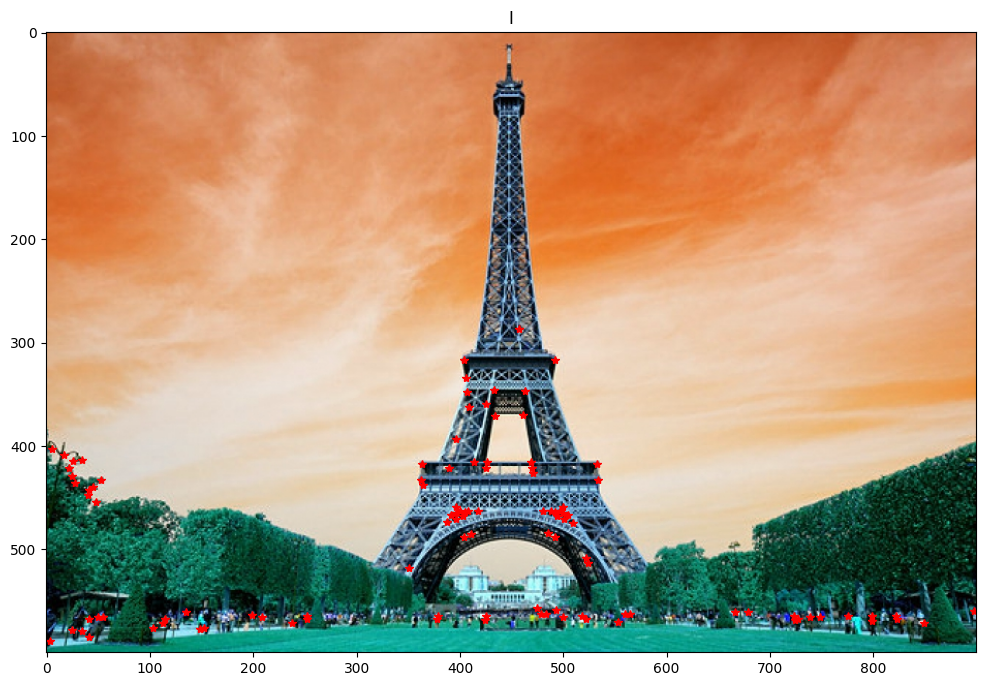

In [4]:
H_norm = fp_harris.Harris(cv2.cvtColor(I, cv2.COLOR_RGB2GRAY), 7, 7)

points = fp_harris.find_max(H_norm, 5, 0.4)

fp_harris.plot_Harris(I, points)

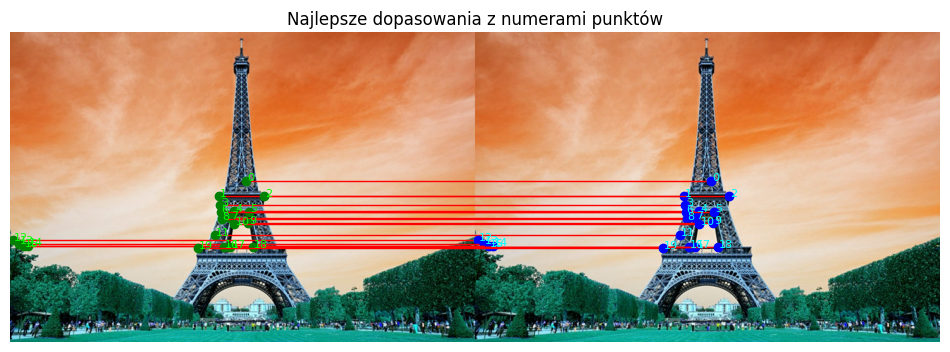

In [5]:

# Harris corner detection
H1 = fp_harris.Harris(cv2.cvtColor(I, cv2.COLOR_RGB2GRAY), sobel_size=7, gauss_size=7)
H2 = fp_harris.Harris(cv2.cvtColor(J, cv2.COLOR_RGB2GRAY), sobel_size=7, gauss_size=7)

# Znalezienie punktów maksymalnych
pts1 = fp_harris.find_max(H1, size=5, threshold=0.4)
pts2 = fp_harris.find_max(H2, size=5, threshold=0.4)

# Tworzenie deskryptorów
desc1 = fp_harris.describe_points2(H1, pts1, size=3)
desc2 = fp_harris.describe_points2(H2, pts2, size=3)

# Dopasowanie deskryptorów
matches = fp_harris.match_descriptors(desc1, desc2, n=20)

fp_harris.plot_matches(I, J, matches)


## ORB (FAST+BRIEF)

/tmp/ipykernel_24744/382934645.py:11: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  self.brief_pairs = np.loadtxt(brief_file, dtype=int)
/tmp/ipykernel_24744/382934645.py:19: RuntimeWarning: overflow encountered in scalar add
  brighter = [pt > p + self.threshold for pt in circle]
/tmp/ipykernel_24744/382934645.py:20: RuntimeWarning: overflow encountered in scalar subtract
  darker = [pt < p - self.threshold for pt in circle]


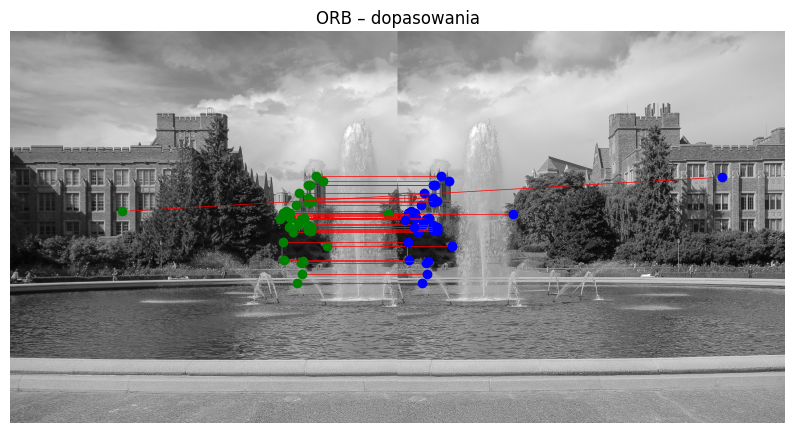

In [13]:
from math import cos, sin, atan2

class FASTORB:
    def __init__(self, threshold=20, patch_size=31, max_keypoints=256, brief_file="orb_descriptor_positions.txt"):
        self.threshold = threshold
        self.patch_size = patch_size
        self.max_keypoints = max_keypoints
        self.margin = patch_size // 2
        self.offsets = [(0, -3), (1, -3), (2, -2), (3, -1), (3, 0), (3, 1), (2, 2),
                        (1, 3), (0, 3), (-1, 3), (-2, 2), (-3, 1), (-3, 0), (-3, -1), (-2, -2), (-1, -3)]
        self.brief_pairs = np.loadtxt(brief_file, dtype=int)

    def detect_FAST(self, img):
        keypoints = []
        for y in range(3, img.shape[0] - 3):
            for x in range(3, img.shape[1] - 3):
                p = img[y, x]
                circle = [img[y + dy, x + dx] for dx, dy in self.offsets]
                brighter = [pt > p + self.threshold for pt in circle]
                darker = [pt < p - self.threshold for pt in circle]
                for i in range(16):
                    if sum(brighter[i:i+9]) == 9 or sum(darker[i:i+9]) == 9:
                        keypoints.append((y, x))
                        break
        return keypoints

    def compute_harris_response(self, img):
        Ix = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        Iy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        Ix2 = cv2.GaussianBlur(Ix * Ix, (3, 3), 0)
        Iy2 = cv2.GaussianBlur(Iy * Iy, (3, 3), 0)
        Ixy = cv2.GaussianBlur(Ix * Iy, (3, 3), 0)
        det = Ix2 * Iy2 - Ixy ** 2
        trace = Ix2 + Iy2
        return det - 0.05 * (trace ** 2)

    def non_max_suppression(self, points, harris_map):
        filtered = []
        for pt in points:
            y, x = pt
            region = harris_map[y-1:y+2, x-1:x+2]
            if harris_map[y, x] == np.max(region):
                filtered.append(pt)
        return filtered

    def filter_and_sort(self, points, harris_map, img_shape):
        valid = [(pt, harris_map[pt]) for pt in points
                 if self.margin <= pt[0] < img_shape[0] - self.margin and self.margin <= pt[1] < img_shape[1] - self.margin]
        valid.sort(key=lambda x: -x[1])
        return [pt for pt, _ in valid[:self.max_keypoints]]

    def compute_orientation(self, img, pt):
        y, x = pt
        half = self.patch_size // 2
        patch = img[y-half:y+half+1, x-half:x+half+1]
        m00 = np.sum(patch)
        if m00 == 0:
            return 0
        m10 = np.sum(np.arange(-half, half+1) * np.sum(patch, axis=0))
        m01 = np.sum(np.arange(-half, half+1) * np.sum(patch, axis=1))
        return atan2(m01, m10)

    def rotate(self, pt, angle):
        x, y = pt
        return (
            int(round(cos(angle) * x - sin(angle) * y)),
            int(round(sin(angle) * x + cos(angle) * y))
        )

    def compute_brief(self, img, pts, angles):
        descs = []
        half = self.patch_size // 2
        for (y, x), angle in zip(pts, angles):
            patch = cv2.GaussianBlur(img[y-half:y+half+1, x-half:x+half+1], (5, 5), 0)
            desc = []
            for dx1, dy1, dx2, dy2 in self.brief_pairs:
                x1, y1 = self.rotate((dx1, dy1), angle)
                x2, y2 = self.rotate((dx2, dy2), angle)
                if all(-half <= v <= half for v in [x1, y1, x2, y2]):
                    p1 = patch[y1 + half, x1 + half]
                    p2 = patch[y2 + half, x2 + half]
                    desc.append(int(p1 < p2))
                else:
                    desc.append(0)
            descs.append(np.array(desc, dtype=np.uint8))
        return descs

    def match_descriptors(self, desc1, desc2, max_matches=40):
        matches = []
        for i, d1 in enumerate(desc1):
            best = 256
            idx = -1
            for j, d2 in enumerate(desc2):
                dist = np.count_nonzero(d1 != d2)
                if dist < best:
                    best = dist
                    idx = j
            matches.append((i, idx, best))
        matches.sort(key=lambda x: x[2])
        return matches[:max_matches]

    def draw_matches(self, img1, pts1, img2, pts2, matches):
        h1, w1 = img1.shape
        h2, w2 = img2.shape
        canvas = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)
        canvas[:h1, :w1] = img1
        canvas[:h2, w1:w1 + w2] = img2
        plt.figure(figsize=(10, 8))
        plt.imshow(canvas, cmap='gray')
        for i1, i2, _ in matches:
            y1, x1 = pts1[i1]
            y2, x2 = pts2[i2]
            plt.plot([x1, x2 + w1], [y1, y2], 'r-', linewidth=0.5)
            plt.plot(x1, y1, 'go')
            plt.plot(x2 + w1, y2, 'bo')
        plt.axis('off')
        plt.title('ORB – dopasowania')
        plt.show()

    def run(self, img1, img2):
        kp1 = self.detect_FAST(img1)
        harris1 = self.compute_harris_response(img1)
        kp1 = self.non_max_suppression(kp1, harris1)
        kp1 = self.filter_and_sort(kp1, harris1, img1.shape)
        ang1 = [self.compute_orientation(img1, pt) for pt in kp1]
        desc1 = self.compute_brief(img1, kp1, ang1)

        kp2 = self.detect_FAST(img2)
        harris2 = self.compute_harris_response(img2)
        kp2 = self.non_max_suppression(kp2, harris2)
        kp2 = self.filter_and_sort(kp2, harris2, img2.shape)
        ang2 = [self.compute_orientation(img2, pt) for pt in kp2]
        desc2 = self.compute_brief(img2, kp2, ang2)

        matches = self.match_descriptors(desc1, desc2)
        self.draw_matches(img1, kp1, img2, kp2, matches)

img1 = cv2.imread("fontanna1.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("fontanna2.jpg", cv2.IMREAD_GRAYSCALE)
orb = FASTORB()
orb.run(img1, img2)

## Wykorzystanie punktów charakterystycznych do ł ˛aczenia obrazów

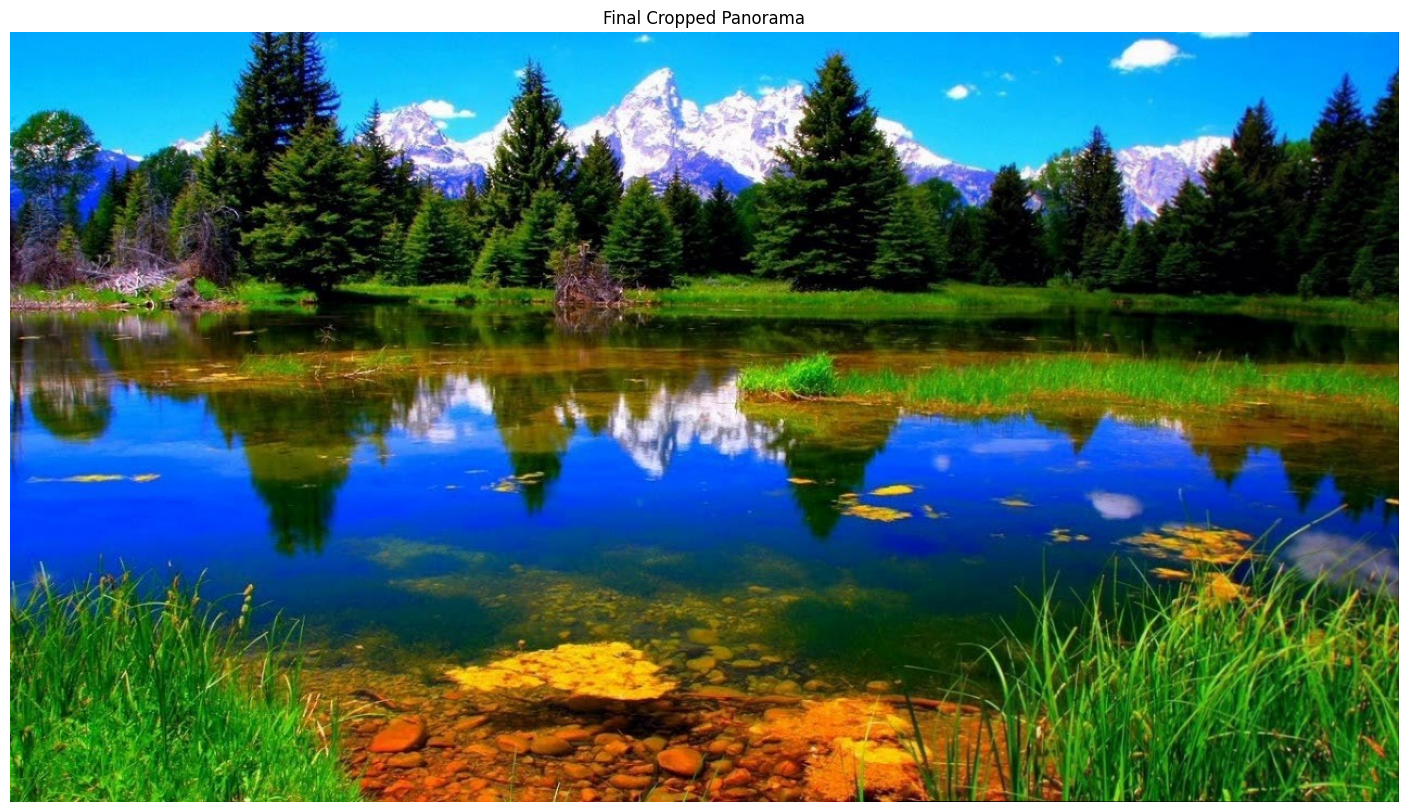

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class PanoramaStitcher:
    def __init__(self, detector='SIFT', nfeatures=2000, debug=False):
        self.debug = debug
        if detector == 'SIFT':
            self.detector = cv2.SIFT_create(nfeatures=nfeatures)
            self.norm_type = cv2.NORM_L2
        else:
            self.detector = cv2.ORB_create(nfeatures=nfeatures)
            self.norm_type = cv2.NORM_HAMMING

    def load_and_convert(self, left_path, right_path):
        self.img_left = cv2.imread(left_path)
        self.img_right = cv2.imread(right_path)

        if self.img_left is None or self.img_right is None:
            raise FileNotFoundError("Could not load images. Check paths.")

        self.gray_left = cv2.cvtColor(self.img_left, cv2.COLOR_BGR2GRAY)
        self.gray_right = cv2.cvtColor(self.img_right, cv2.COLOR_BGR2GRAY)

        if self.debug:
            fig, ax = plt.subplots(1, 2, figsize=(16, 8))
            ax[0].imshow(self.gray_left, cmap='gray')
            ax[0].set_title("Left - Gray")
            ax[1].imshow(self.gray_right, cmap='gray')
            ax[1].set_title("Right - Gray")
            plt.show()

    def detect_and_compute(self):
        self.kp_left, self.desc_left = self.detector.detectAndCompute(self.gray_left, None)
        self.kp_right, self.desc_right = self.detector.detectAndCompute(self.gray_right, None)

        if self.debug:
            img_kp_left = cv2.drawKeypoints(self.img_left, self.kp_left, None, color=(0, 255, 0))
            img_kp_right = cv2.drawKeypoints(self.img_right, self.kp_right, None, color=(0, 255, 0))

            fig, ax = plt.subplots(1, 2, figsize=(16, 8))
            ax[0].imshow(cv2.cvtColor(img_kp_left, cv2.COLOR_BGR2RGB))
            ax[0].set_title("Keypoints - Left")
            ax[1].imshow(cv2.cvtColor(img_kp_right, cv2.COLOR_BGR2RGB))
            ax[1].set_title("Keypoints - Right")
            plt.show()

    def match_keypoints(self):
        matcher = cv2.BFMatcher(self.norm_type)
        raw_matches = matcher.knnMatch(self.desc_left, self.desc_right, k=2)

        self.good_matches = [m for m, n in raw_matches if m.distance < 0.75 * n.distance]

        if self.debug:
            matched_img = cv2.drawMatches(
                self.img_left, self.kp_left,
                self.img_right, self.kp_right,
                self.good_matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
            )
            plt.figure(figsize=(20, 10))
            plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
            plt.title("Good Matches (Top 50)")
            plt.axis('off')
            plt.show()

    def compute_homography(self):
        if len(self.good_matches) < 4:
            raise ValueError("Not enough good matches to compute homography.")

        ptsA = np.float32([self.kp_left[m.queryIdx].pt for m in self.good_matches])
        ptsB = np.float32([self.kp_right[m.trainIdx].pt for m in self.good_matches])
        self.H, _ = cv2.findHomography(ptsA, ptsB, cv2.RANSAC)

        if self.H is None:
            raise ValueError("Homography computation failed!")

    def stitch(self):
        width = self.img_left.shape[1] + self.img_right.shape[1]
        height = max(self.img_left.shape[0], self.img_right.shape[0])
        self.result = cv2.warpPerspective(self.img_left, self.H, (width, height))
        self.result[0:self.img_right.shape[0], 0:self.img_right.shape[1]] = self.img_right

        if self.debug:
            plt.figure(figsize=(20, 10))
            plt.imshow(cv2.cvtColor(self.result, cv2.COLOR_BGR2RGB))
            plt.title("Stitched Image (Before Cropping)")
            plt.axis('off')
            plt.show()

    def crop_result(self):
        gray = cv2.cvtColor(self.result, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            raise ValueError("No valid contours found in the result image.")

        # wybieramy największy kontur (najpewniej to jest obraz)
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        self.result_cropped = self.result[y:y+h, x:x+w]

        if self.debug:
            print(f"Cropping to: x={x}, y={y}, w={w}, h={h}")
            plt.figure(figsize=(10, 5))
            plt.imshow(cv2.cvtColor(self.result_cropped, cv2.COLOR_BGR2RGB))
            plt.title("Cropped Result Preview")
            plt.axis('off')
            plt.show()


    def show_result(self):
        plt.figure(figsize=(20, 10))
        plt.imshow(cv2.cvtColor(self.result_cropped, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("Final Cropped Panorama")
        plt.show()

    def process(self, left_path, right_path):
        self.load_and_convert(left_path, right_path)
        self.detect_and_compute()
        self.match_keypoints()
        self.compute_homography()
        self.stitch()
        self.crop_result()
        self.show_result()



stitcher = PanoramaStitcher(detector='ORB')  # lub 'SIFT'
stitcher.process('left_panorama.jpg', 'right_panorama.jpg')

## SIFT

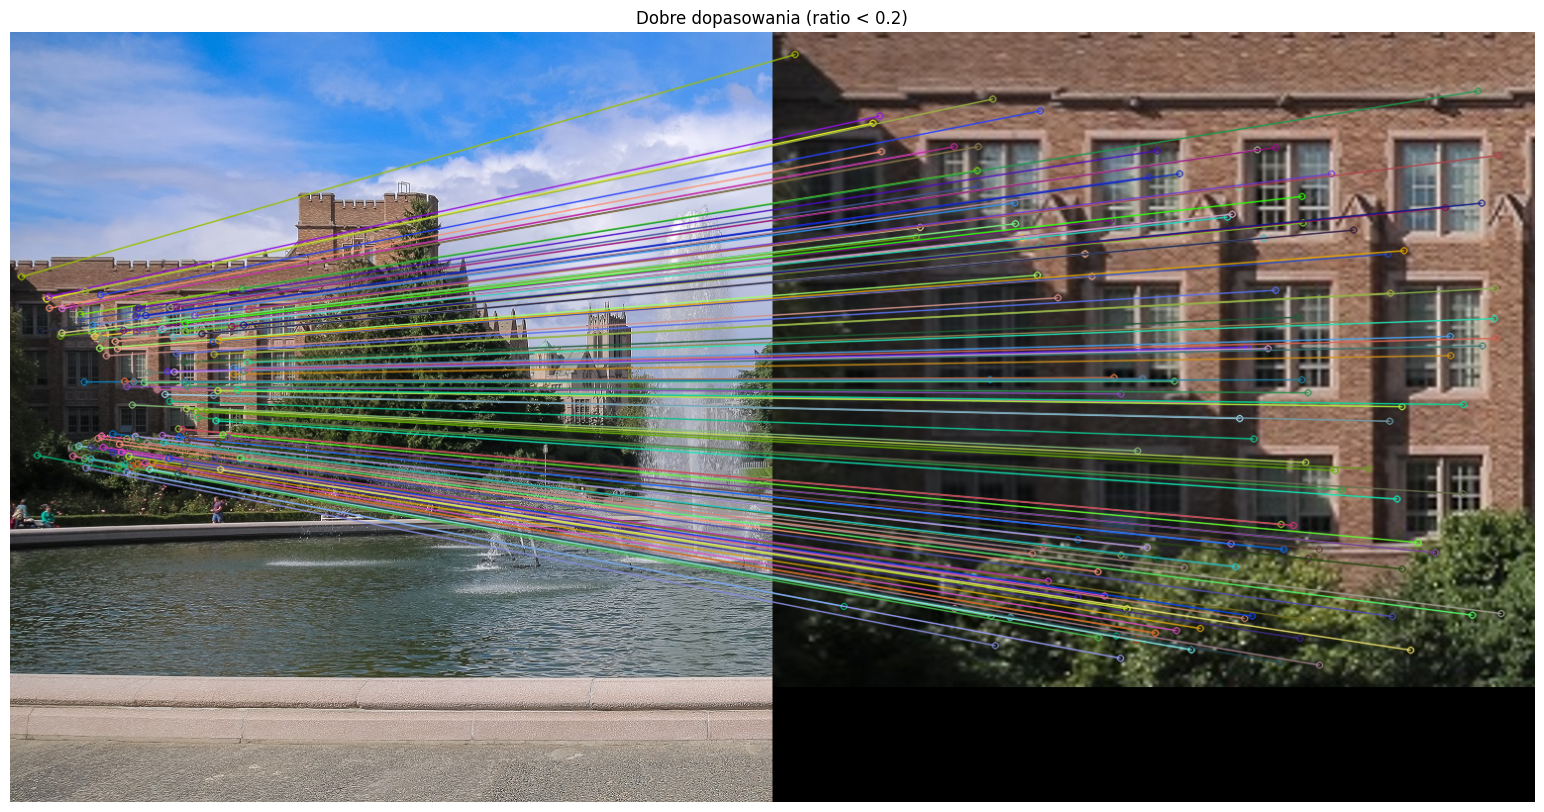

In [17]:
class SIFTMatcher:
    def __init__(self, ratio_thresh=0.5):
        self.sift = cv2.SIFT_create()
        self.matcher = cv2.BFMatcher(cv2.NORM_L2)
        self.ratio_thresh = ratio_thresh

    def load_images(self, img1_path, img2_path):
        self.img1 = cv2.imread(img1_path)
        self.img2 = cv2.imread(img2_path)
        
        if self.img1 is None or self.img2 is None:
            raise FileNotFoundError("One or both image paths are incorrect.")
        
        self.gray1 = cv2.cvtColor(self.img1, cv2.COLOR_BGR2GRAY)
        self.gray2 = cv2.cvtColor(self.img2, cv2.COLOR_BGR2GRAY)

    def detect_and_compute(self):
        self.kp1, self.desc1 = self.sift.detectAndCompute(self.gray1, None)
        self.kp2, self.desc2 = self.sift.detectAndCompute(self.gray2, None)

    def match_features(self):
        raw_matches = self.matcher.knnMatch(self.desc1, self.desc2, k=2)

        # Lowe’s ratio test
        self.good_matches = [
            [m] for m, n in raw_matches if m.distance < self.ratio_thresh * n.distance
        ]

    def draw_matches(self):
        matched_img = cv2.drawMatchesKnn(
            self.img1, self.kp1,
            self.img2, self.kp2,
            self.good_matches,
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        plt.figure(figsize=(20, 10))
        plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
        plt.title(f'Dobre dopasowania (ratio < {self.ratio_thresh})')
        plt.axis('off')
        plt.show()

    def process(self, img1_path, img2_path):
        self.load_images(img1_path, img2_path)
        self.detect_and_compute()
        self.match_features()
        self.draw_matches()

matcher = SIFTMatcher(ratio_thresh=0.2)
matcher.process('fontanna1.jpg', 'fontanna_pow.jpg')
